In [12]:
# ----------------------------------------
# quick_morphology_metrics.py
# ----------------------------------------
import json, math
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
from skimage import measure, morphology

# ---------- core metric function ----------
def shape_metrics(mask_bin: np.ndarray, px_um: float):
    """Return shape metrics (largest region) in physical units."""
    # regionprops wants integer labels
    regions = measure.regionprops(mask_bin.astype(int))
    if not regions:
        return None  # empty mask

    props = max(regions, key=lambda r: r.area)  # largest region
    area_px  = props.area
    peri_px  = props.perimeter
    major_px = props.major_axis_length
    minor_px = props.minor_axis_length

    hull     = morphology.convex_hull_image(mask_bin)
    peri_ch_px  = measure.perimeter(hull)
    area_ch_px  = hull.sum()

    circularity = 4 * math.pi * area_px / (peri_px ** 2)
    solidity    = area_px / area_ch_px
    convexity   = peri_ch_px / peri_px
    aspect      = major_px / minor_px
    roughness   = peri_px / peri_ch_px

    # convert to microns
    um = px_um
    return dict(
        area_um2     = area_px  * um ** 2,
        perimeter_um = peri_px  * um,
        major_um     = major_px * um,
        minor_um     = minor_px * um,
        circularity  = circularity,
        solidity     = solidity,
        convexity    = convexity,
        roughness    = roughness,
        aspect_ratio = aspect,
    )

# ---------- iterate over every mapping ----------
root = Path("/net/projects2/promega/data-analysis/output/processed_dataset_256x192")
out_rows = []

for jp in root.rglob("image_mapping_*_processed.json"):
    mapping = json.loads(jp.read_text())
    print("•", jp.relative_to(root))
    for img_id, info in mapping.items():
        mask_path = Path(info["mask_path"])
        if not mask_path.exists():
            print("  ⚠️  missing mask:", mask_path.name)
            continue

        mask_bin = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE) > 127
        if mask_bin.sum() == 0:
            print("  ⚠️  empty mask:", mask_path.name)
            continue

        m = shape_metrics(mask_bin, info["final_um_per_px"])
        if m:
            m.update(
                img_id     = img_id,
                batch_day  = mask_path.parts[-4],       # e.g. batch2_96_1/day03
            )
            out_rows.append(m)

# ---------- save ----------
df = pd.DataFrame(out_rows)
out_csv = root / "morphology_metrics.csv"
df.to_csv(out_csv, index=False)
print(f"\nSaved {len(df)} objects →  {out_csv}")


• BA2_96_2_Dy06/image_mapping_BA2_96_2_Dy06_processed.json
  ⚠️  empty mask: Ba2_96_2_Dy06_H12_predmask.png
• BA3_Dy08/image_mapping_BA3_Dy08_processed.json
  ⚠️  empty mask: Ba3_Pt1_Dy08_D9_predmask.png
• BA3_Dy30/image_mapping_BA3_Dy30_processed.json
• BA2_96_2_Dy15/image_mapping_BA2_96_2_Dy15_processed.json
• BA1_Dy13/image_mapping_BA1_Dy13_processed.json
• BA3_Dy24/image_mapping_BA3_Dy24_processed.json
• BA2_96_1_Dy21/image_mapping_BA2_96_1_Dy21_processed.json
  ⚠️  empty mask: Ba2_96_1_Dy21_A1_predmask.png
  ⚠️  empty mask: Ba2_96_1_Dy21_B12_predmask.png
• BA2_96_1_Dy13/image_mapping_BA2_96_1_Dy13_processed.json
• BA2_96_1_Dy17/image_mapping_BA2_96_1_Dy17_processed.json
• BA1_Dy17/image_mapping_BA1_Dy17_processed.json
• BA2_96_2_Dy24/image_mapping_BA2_96_2_Dy24_processed.json
  ⚠️  empty mask: Ba2_96_2_Dy24_A10_predmask.png
  ⚠️  empty mask: Ba2_96_2_Dy24_A12_predmask.png
  ⚠️  empty mask: Ba2_96_2_Dy24_A8_predmask.png
• BA1_Dy10/image_mapping_BA1_Dy10_processed.json
• BA2_96_1_Dy

In [7]:
import json
import math
import cv2
import numpy as np
import pandas as pd

from pathlib import Path
from skimage import measure, morphology
from scipy.stats import entropy as shannon_entropy
from skimage.measure import find_contours
from pyefd import elliptic_fourier_descriptors, reconstruct_contour

# ── 1) your classic shape metrics ────────────────────────────────────────
def classic_shape_metrics(mask_bin: np.ndarray, μm_per_px: float):
    regions = measure.regionprops(mask_bin.astype(int))
    if not regions:
        return None
    props   = max(regions, key=lambda r: r.area)
    area_px = props.area
    peri_px = props.perimeter
    major   = props.major_axis_length
    minor   = props.minor_axis_length

    hull     = morphology.convex_hull_image(mask_bin)
    peri_ch  = measure.perimeter(hull)
    area_ch  = hull.sum()

    return {
        "area_um2"     : area_px  * μm_per_px**2,
        "perimeter_um" : peri_px  * μm_per_px,
        "major_um"     : major    * μm_per_px,
        "minor_um"     : minor    * μm_per_px,
        "circularity"  : 4*math.pi*area_px/(peri_px**2),
        "solidity"     : area_px/area_ch,
        "convexity"    : peri_ch/peri_px,
        "aspect_ratio" : major/minor,
    }

# ── 2) the LOCO-EFA “timbre” metrics ────────────────────────────────────
def efa_timbre_metrics(mask_bin: np.ndarray,
                       μm_per_px: float,
                       n_harmonics: int = 15):
    from skimage.measure import find_contours
    from pyefd import elliptic_fourier_descriptors, reconstruct_contour

    # 1) get largest contour
    contours = find_contours(mask_bin.astype(int), level=0.5)
    if not contours:
        return None
    contour = max(contours, key=len)
    xy = np.fliplr(contour)

    # 2) EFD coefficients
    coeffs = elliptic_fourier_descriptors(xy, order=n_harmonics, normalize=True)

    orig_area = mask_bin.sum() * (μm_per_px**2)
    xor_curve = np.zeros(n_harmonics + 1, float)
    xor_curve[0] = orig_area

    for k in range(1, n_harmonics + 1):
        rec_xy = reconstruct_contour(
            coeffs[:k],
            locus=(0, 0),
            num_points=xy.shape[0]
        )
        pts = np.round(rec_xy).astype(np.int32)

        # draw into uint8, then to bool
        ui     = np.zeros(mask_bin.shape, np.uint8)
        cv2.fillPoly(ui, [pts], 1)
        filled = ui.astype(bool)

        xor_curve[k] = np.logical_xor(mask_bin, filled).sum() * (μm_per_px**2)

    marginal   = xor_curve[:-1] - xor_curve[1:]
    cumulative = xor_curve[2:].sum()

    amps = np.sqrt((coeffs**2).sum(axis=1))
    p    = amps / (amps.sum() + 1e-12)
    E    = shannon_entropy(p)

    return {
        "xor_curve"      : xor_curve.tolist(),
        "marginal_diff"  : marginal.tolist(),
        "cumulative_diff": float(cumulative),
        "entropy"        : float(E),
    }

# ── 3) iterate over your mappings, merge both sets of metrics ────────────
root    = Path("/net/projects2/promega/data-analysis/output/processed_dataset_256x192")
out_rows = []

for jp in root.rglob("image_mapping_*_processed.json"):
    mapping = json.loads(jp.read_text())
    for img_id, info in mapping.items():
        mp = info["final_um_per_px"]
        mask = cv2.imread(info["mask_path"], cv2.IMREAD_GRAYSCALE) > 127
        if not mask.sum():
            continue

        classic = classic_shape_metrics(mask, mp)
        if classic is None:
            continue

        efa = efa_timbre_metrics(mask, mp, n_harmonics=15)

        row = {
            "img_id"    : img_id,
            "batch_day" : Path(info["mask_path"]).parts[-4],
            **classic,
            **efa
        }
        out_rows.append(row)

# ── 4) save to CSV ─────────────────────────────────────────────────────
df = pd.DataFrame(out_rows)
out_csv = root/"morphology_timbre_metrics.csv"
df.to_csv(out_csv, index=False)
print(f"Saved {len(df)} objects → {out_csv}")


Saved 4051 objects → /net/projects2/promega/data-analysis/output/processed_dataset_256x192/morphology_timbre_metrics.csv


In [8]:

csv_path = Path("/net/projects2/promega/data-analysis/output/processed_dataset_256x192/morphology_timbre_metrics.csv")
df = pd.read_csv(csv_path)

In [9]:
print(df.columns)
print(df.head())

Index(['img_id', 'batch_day', 'area_um2', 'perimeter_um', 'major_um',
       'minor_um', 'circularity', 'solidity', 'convexity', 'aspect_ratio',
       'xor_curve', 'marginal_diff', 'cumulative_diff', 'entropy'],
      dtype='object')
              img_id    batch_day       area_um2  perimeter_um     major_um  \
0   Ba2 96_2 Dy06 A1  batch2_96_2     939.936403     86.715000    48.475159   
1  Ba2 96_2 Dy06 A10  batch2_96_2  605789.011814   2934.147643   910.228761   
2  Ba2 96_2 Dy06 A11  batch2_96_2  648203.642005   3046.712128   933.181925   
3  Ba2 96_2 Dy06 A12  batch2_96_2  714469.158425   3343.865069  1060.038120   
4   Ba2 96_2 Dy06 A2  batch2_96_2  715644.078929   3186.853672   974.420035   

     minor_um  circularity  solidity  convexity  aspect_ratio  \
0   21.678750     1.570796  1.000000   1.000000      2.236068   
1  850.953142     0.884234  0.977255   1.000000      1.069658   
2  889.715051     0.877523  0.976979   1.000000      1.048855   
3  872.388143     0.802964  0.

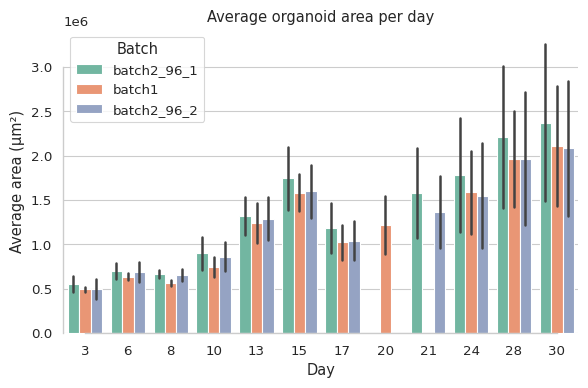

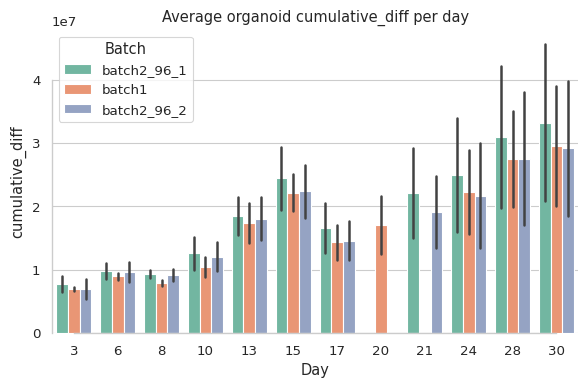

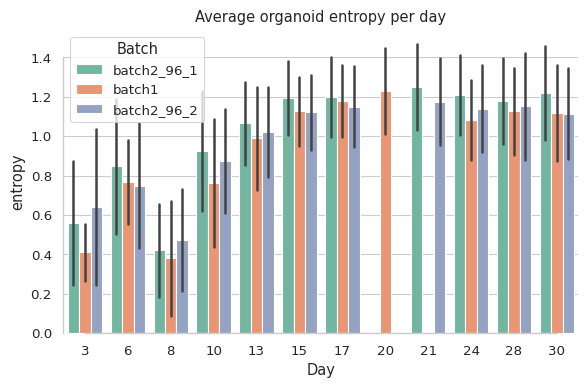

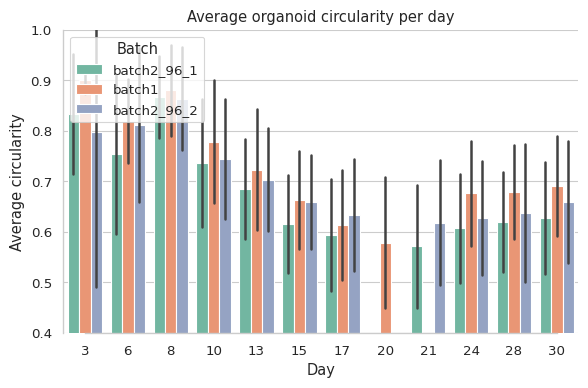

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Load data
#csv_path = Path("/net/projects2/promega/data-analysis/output/processed_dataset_256x192/morphology_metrics.csv")
df = pd.read_csv(csv_path)

# Filter and preprocess
df = df[df["batch_day"].isin(["batch1", "batch2_96_1", "batch2_96_2"])].copy()
df["day"] = df["img_id"].str.extract(r"Dy(\d+)", expand=False).astype(int)
df["batch"] = df["batch_day"]

# Seaborn theme
sns.set_theme(
    context="paper",
    style="whitegrid",
    palette="Set2",
    font="DejaVu Sans",
    font_scale=1.1
)

# Function for bar plots
def plot_bar(metric, ylabel, title, ylim=None):
    plt.figure(figsize=(6, 4))
    sns.barplot(
        data=df, x="day", y=metric, hue="batch",
        errorbar="sd", palette="Set2"
    )
    plt.ylabel(ylabel)
    plt.xlabel("Day")
    plt.title(title)
    if ylim:
        plt.ylim(ylim)
    plt.legend(title="Batch", loc="upper left")
    sns.despine(trim=True)
    plt.tight_layout()
    plt.show()

# Plotting
plot_bar("area_um2", "Average area (µm²)", "Average organoid area per day")
plot_bar("cumulative_diff", "cumulative_diff", "Average organoid cumulative_diff per day")
plot_bar("entropy", "entropy", "Average organoid entropy per day")
plot_bar("circularity", "Average circularity", "Average organoid circularity per day", ylim=(0.4, 1))


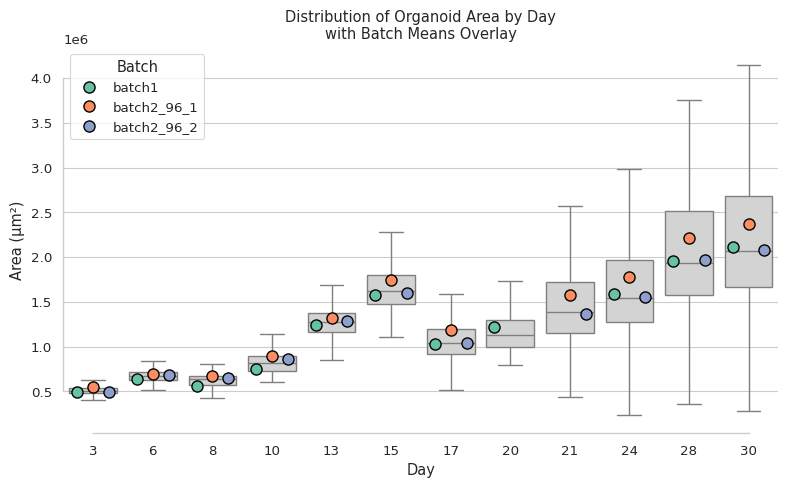

In [12]:
df = df[df["batch_day"].isin(["batch1", "batch2_96_1", "batch2_96_2"])].copy()
df["day"]   = df["img_id"].str.extract(r"Dy(\d+)", expand=False).astype(int)
df["batch"] = df["batch_day"]
metric = "area_um2"

# 2) Compute batch‐day means
means = df.groupby(["batch","day"])[metric].mean().reset_index()

# 3) Plot
sns.set_theme(context="paper", style="whitegrid", palette="Set2", font="sans-serif", font_scale=1.1)
plt.figure(figsize=(8,5))

# A) The grey boxplot of *all* measurements by day
ax = sns.boxplot(
    data=df,
    x="day", y=metric,
    color="lightgray",
    showfliers=False
)

# B) Overlay batch means with dodge=True so they align under each day
sns.stripplot(
    data=means,
    x="day", y=metric,
    hue="batch",
    palette="Set2",
    dodge=True,        # align under each day
    size=8,
    marker="o",
    edgecolor="k",
    linewidth=1,
    ax=ax
)

# 4) Final touches
ax.set_xlabel("Day")
ax.set_ylabel("Area (µm²)")
ax.set_title("Distribution of Organoid Area by Day\nwith Batch Means Overlay")
sns.despine(trim=True)
plt.legend(title="Batch", loc="upper left")
plt.tight_layout()
plt.show()